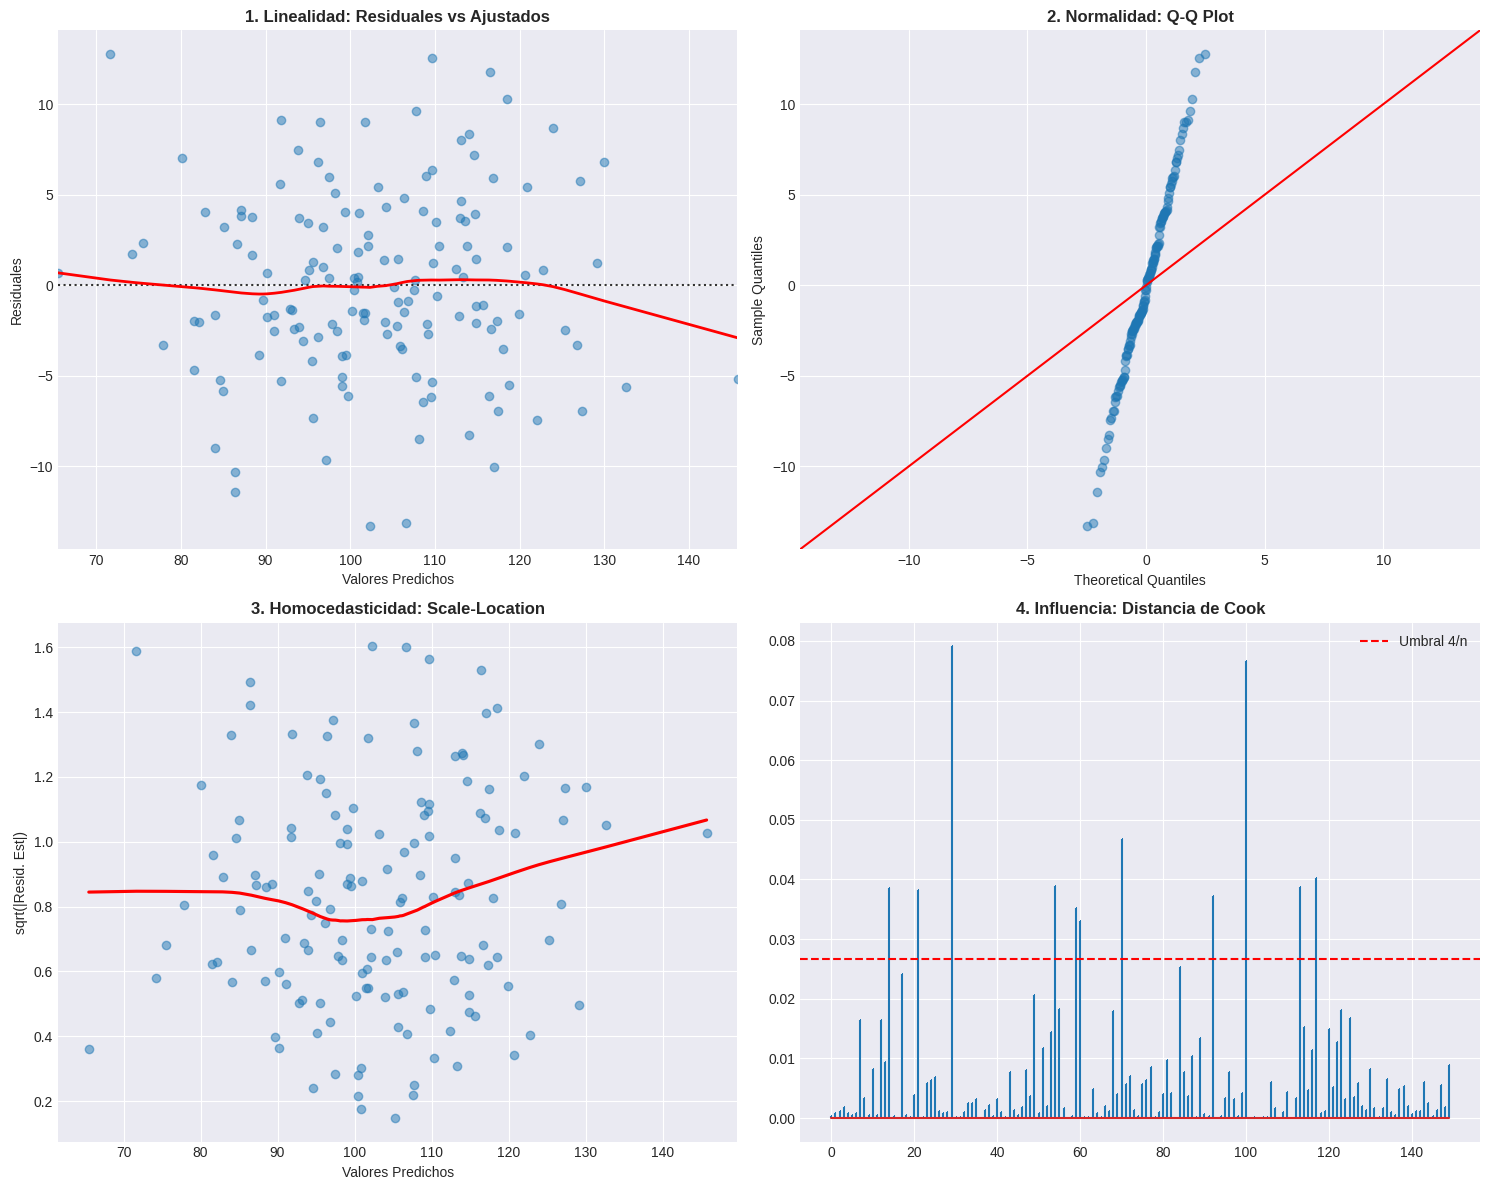


RESUMEN DE REGRESIÓN (PhD LEVEL)
                            OLS Regression Results                            
Dep. Variable:             captura_kg   R-squared:                       0.872
Model:                            OLS   Adj. R-squared:                  0.869
Method:                 Least Squares   F-statistic:                     330.4
Date:                Sat, 09 May 2026   Prob (F-statistic):           7.51e-65
Time:                        17:06:18   Log-Likelihood:                -457.68
No. Observations:                 150   AIC:                             923.4
Df Residuals:                     146   BIC:                             935.4
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------

In [ ]:
# %% [code]
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import shapiro, levene
from scipy.signal import savgol_filter
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.outliers_influence import variance_inflation_factor as VIF
from statsmodels.graphics.gofplots import ProbPlot
import warnings

# Configuración inicial
warnings.filterwarnings('ignore')
try:
    plt.style.use('seaborn-v0_8-darkgrid')
except:
    plt.style.use('ggplot')

# ==========================================
# 1. GENERACIÓN DEL DATASET SINTÉTICO
# ==========================================
np.random.seed(42)
n_observations = 150

data = {
    'id_pescador': np.arange(1, n_observations + 1),
    'horas_faena': np.random.normal(loc=6.5, scale=1.2, size=n_observations),
    'tamanio_embarcacion_m': np.random.normal(loc=7.2, scale=2.1, size=n_observations),
    'experiencia_anios': np.random.uniform(1, 45, size=n_observations),
    'temperatura_agua_C': np.random.normal(loc=24.5, scale=1.8, size=n_observations),
}

# Proceso de generación de Y (Captura)
beta_0, beta_1, beta_2, beta_3 = 15.0, 8.5, 3.2, 0.4
epsilon = np.random.normal(loc=0, scale=5.0, size=n_observations)

data['captura_kg'] = (beta_0 +
                      beta_1 * data['horas_faena'] +
                      beta_2 * data['tamanio_embarcacion_m'] +
                      beta_3 * data['experiencia_anios'] +
                      epsilon)

df = pd.DataFrame(data)
df['captura_kg'] = np.maximum(df['captura_kg'], 5) # Evitar valores negativos

# ==========================================
# 2. MODELADO (REGRESIÓN MÚLTIPLE)
# ==========================================
modelo_multiple = ols('captura_kg ~ horas_faena + tamanio_embarcacion_m + experiencia_anios', data=df).fit()

# ==========================================
# 3. DIAGNÓSTICOS DE SUPUESTOS
# ==========================================
residuals = modelo_multiple.resid
fitted_values = modelo_multiple.fittedvalues
influence = modelo_multiple.get_influence()
std_residuals = influence.resid_studentized_internal
cooks_d = influence.cooks_distance[0]
leverage = influence.hat_matrix_diag

# Visualización Maestra de Diagnósticos
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# A. Linealidad (Residuales vs Ajustados)
sns.residplot(x=fitted_values, y=residuals, lowess=True, ax=axes[0,0],
              line_kws={'color': 'red', 'lw': 2}, scatter_kws={'alpha': 0.5})
axes[0,0].set_title('1. Linealidad: Residuales vs Ajustados', fontweight='bold')
axes[0,0].set_xlabel('Valores Predichos')
axes[0,0].set_ylabel('Residuales')

# B. Normalidad (Q-Q Plot)
qq = ProbPlot(residuals)
qq.qqplot(line='45', alpha=0.5, ax=axes[0,1])
axes[0,1].set_title('2. Normalidad: Q-Q Plot', fontweight='bold')

# C. Homocedasticidad (Scale-Location)
axes[1,0].scatter(fitted_values, np.sqrt(np.abs(std_residuals)), alpha=0.5)
sns.regplot(x=fitted_values, y=np.sqrt(np.abs(std_residuals)),
            scatter=False, ci=None, lowess=True, ax=axes[1,0], line_kws={'color': 'red'})
axes[1,0].set_title('3. Homocedasticidad: Scale-Location', fontweight='bold')
axes[1,0].set_xlabel('Valores Predichos')
axes[1,0].set_ylabel('sqrt(|Resid. Est|)')

# D. Influencia (Cook's Distance)
axes[1,1].stem(np.arange(len(cooks_d)), cooks_d, markerfmt=",")
axes[1,1].axhline(y=4/n_observations, color='red', linestyle='--', label='Umbral 4/n')
axes[1,1].set_title('4. Influencia: Distancia de Cook', fontweight='bold')
axes[1,1].legend()

plt.tight_layout()
plt.show()

# ==========================================
# 4. MULTICOLINEALIDAD (VIF)
# ==========================================
X = df[['horas_faena', 'tamanio_embarcacion_m', 'experiencia_anios']]
X_const = sm.add_constant(X)
vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [VIF(X_const.values, i) for i in range(1, X_const.shape[1])]

# ==========================================
# 5. REPORTE FINAL DE RESULTADOS
# ==========================================
print("\n" + "="*50)
print("RESUMEN DE REGRESIÓN (PhD LEVEL)")
print("="*50)
print(modelo_multiple.summary())

print("\n" + "="*50)
print("PRUEBAS DE SUPUESTOS E INDICADORES")
print("="*50)
sw_stat, sw_p = shapiro(residuals)
print(f"Shapiro-Wilk (Normalidad): p-value = {sw_p:.4f} {'(OK)' if sw_p > 0.05 else '(VIOLADO)'}")

print("\n--- Factores de Inflación de Varianza (VIF) ---")
print(vif_data.to_string(index=False))
if vif_data['VIF'].max() < 5:
    print("Multicolinealidad: OK (Baja)")
else:
    print("Multicolinealidad: ALERTA (Alta)")

print("\n--- Detección de Outliers ---")
outliers_idx = np.where(np.abs(std_residuals) > 2)[0]
print(f"Observaciones con residuales > 2 SD: {len(outliers_idx)}")
print(f"Observaciones influyentes (Cook > 4/n): {np.sum(cooks_d > 4/n_observations)}")

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats

# Configuración estética
sns.set_theme(style="whitegrid")

# Generación de dataset sintético (Contexto Costero)
np.random.seed(42)
n = 150
# X1: Temperatura superficial del mar (°C)
temp = np.random.normal(28, 2, n)
# X2: Nivel de nutrientes (mg/L)
nutrientes = np.random.normal(5, 1.5, n)
# X3: Turbidez del agua (NTU) - Altamente correlacionada con nutrientes (para probar VIF)
turbidez = nutrientes * 0.8 + np.random.normal(0, 0.5, n)

# Y: Índice de Biodiversidad (0-100) con un poco de heterocedasticidad inducida
error = np.random.normal(0, 1, n) * (temp / 10)
biodiversidad = 100 - (2.5 * temp) + (1.8 * nutrientes) + error

df = pd.DataFrame({
    'Biodiversidad': biodiversidad,
    'Temperatura': temp,
    'Nutrientes': nutrientes,
    'Turbidez': turbidez
})

print("Dataset costero generado. Primeras 5 filas:")
print(df.head())

Dataset costero generado. Primeras 5 filas:
   Biodiversidad  Temperatura  Nutrientes  Turbidez
0      37.011032    28.993428    5.375739  3.886094
1      43.274718    27.723471    5.519672  4.135647
2      31.037769    29.295377    3.979963  3.557617
3      33.576802    31.046060    5.348381  4.583890
4      39.502174    27.531693    5.439609  4.341236


Guía de Interpretación:Coeficientes: Indican el cambio en la Biodiversidad por cada unidad de incremento en la variable, manteniendo las demás constantes.R²: Proporción de la varianza explicada por el modelo.Prob (F-statistic): Si es $< 0.05$, el modelo es globalmente significativo.

In [ ]:
# Definir variables
X = df[['Temperatura', 'Nutrientes', 'Turbidez']]
X = sm.add_constant(X) # Añadir intercepto
y = df['Biodiversidad']

# Ajustar modelo
modelo = sm.OLS(y, X).fit()

# Visualizar resumen
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:          Biodiversidad   R-squared:                       0.824
Model:                            OLS   Adj. R-squared:                  0.820
Method:                 Least Squares   F-statistic:                     227.1
Date:                Sat, 09 May 2026   Prob (F-statistic):           8.96e-55
Time:                        17:07:16   Log-Likelihood:                -359.71
No. Observations:                 150   AIC:                             727.4
Df Residuals:                     146   BIC:                             739.5
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const         105.3028      3.374     31.214      

¿Qué buscar?

Linealidad: Los puntos en "Residuales vs Ajustados" deben distribuirse al azar sin formas de "U" o "S".

Normalidad: En el Q-Q Plot, los puntos deben seguir la línea recta.

Homocedasticidad: La dispersión de los residuales debe ser constante a lo largo del eje X. Si hay forma de "abanico", hay un problema.

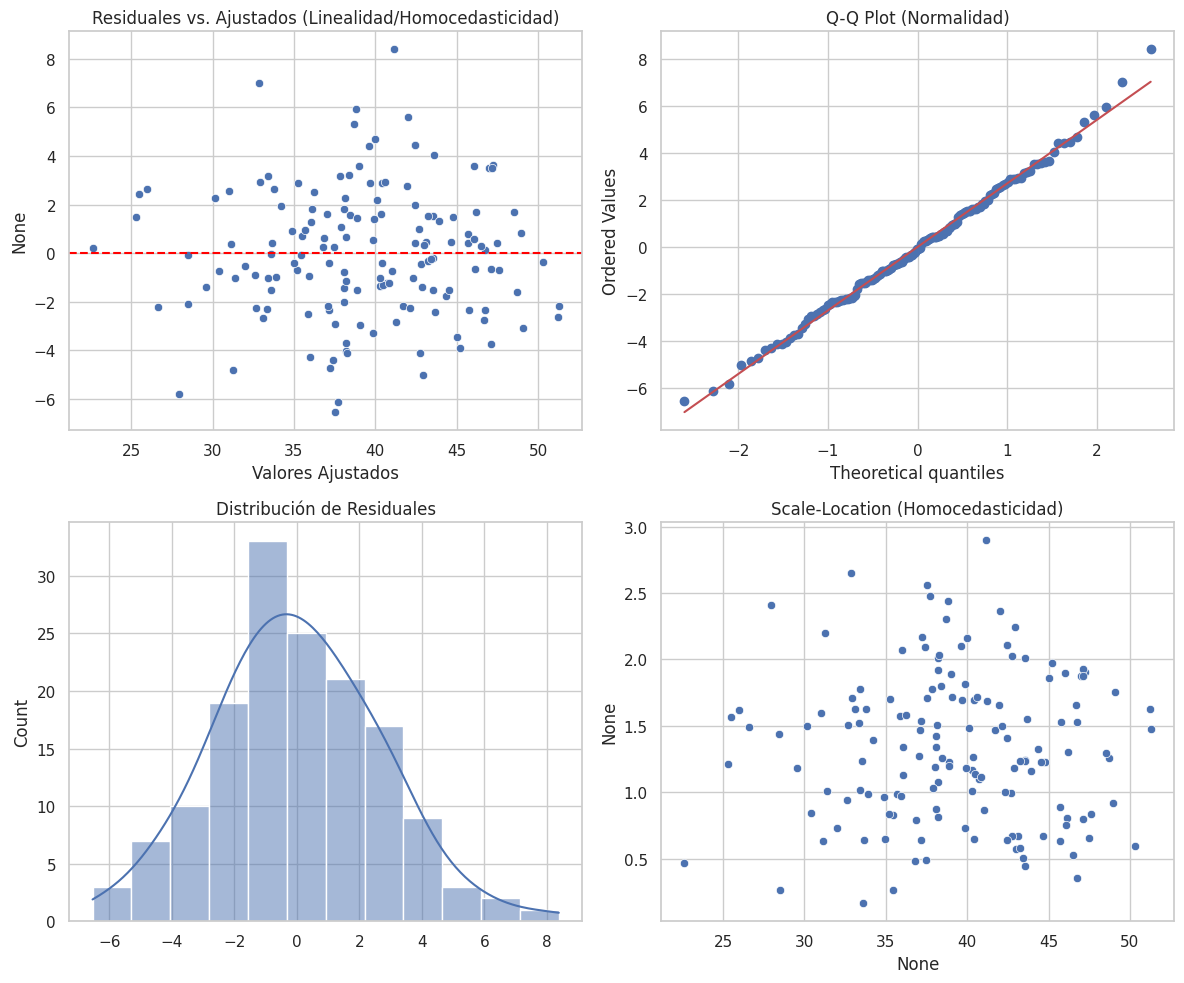

In [ ]:
# Obtener residuales y valores ajustados
fitted_vals = modelo.fittedvalues
residuals = modelo.resid

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# A. Linealidad y Homocedasticidad (Residuales vs Ajustados)
sns.scatterplot(x=fitted_vals, y=residuals, ax=axes[0, 0])
axes[0, 0].axhline(0, color='red', linestyle='--')
axes[0, 0].set_title('Residuales vs. Ajustados (Linealidad/Homocedasticidad)')
axes[0, 0].set_xlabel('Valores Ajustados')
axes[0, 1].set_ylabel('Residuales')

# B. Normalidad (Q-Q Plot)
stats.probplot(residuals, dist="norm", plot=axes[0, 1])
axes[0, 1].set_title('Q-Q Plot (Normalidad)')

# C. Histograma de Residuales
sns.histplot(residuals, kde=True, ax=axes[1, 0])
axes[1, 0].set_title('Distribución de Residuales')

# D. Independencia (Scale-Location)
sns.scatterplot(x=fitted_vals, y=np.sqrt(np.abs(residuals)), ax=axes[1, 1])
axes[1, 1].set_title('Scale-Location (Homocedasticidad)')

plt.tight_layout()
plt.show()

In [ ]:
# Calcular VIF para cada variable
vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]

print("Análisis de Multicolinealidad (VIF):")
print(vif_data.drop(0)) # Quitamos la constante para lectura

Análisis de Multicolinealidad (VIF):
      Variable       VIF
1  Temperatura  1.001737
2   Nutrientes  7.881492
3     Turbidez  7.886366


Regla de oro: Un VIF > 5 o 10 indica una alta multicolinealidad. En este ejemplo, Nutrientes y Turbidez probablemente muestren valores altos.

Estrategia: Si el VIF es alto, considera eliminar la variable menos relevante teóricamente.

In [ ]:
# Ejemplo: Aplicando logaritmo a la variable dependiente si detectamos sesgo
df['Log_Biodiversidad'] = np.log(df['Biodiversidad'] + 1) # +1 para evitar log(0)

# Re-ajuste de modelo transformado
modelo_log = sm.OLS(df['Log_Biodiversidad'], X).fit()

print("Comparativa R² Original vs Log:")
print(f"Original: {modelo.rsquared:.4f} | Transformado: {modelo_log.rsquared:.4f}")

Comparativa R² Original vs Log:
Original: 0.8235 | Transformado: 0.8202


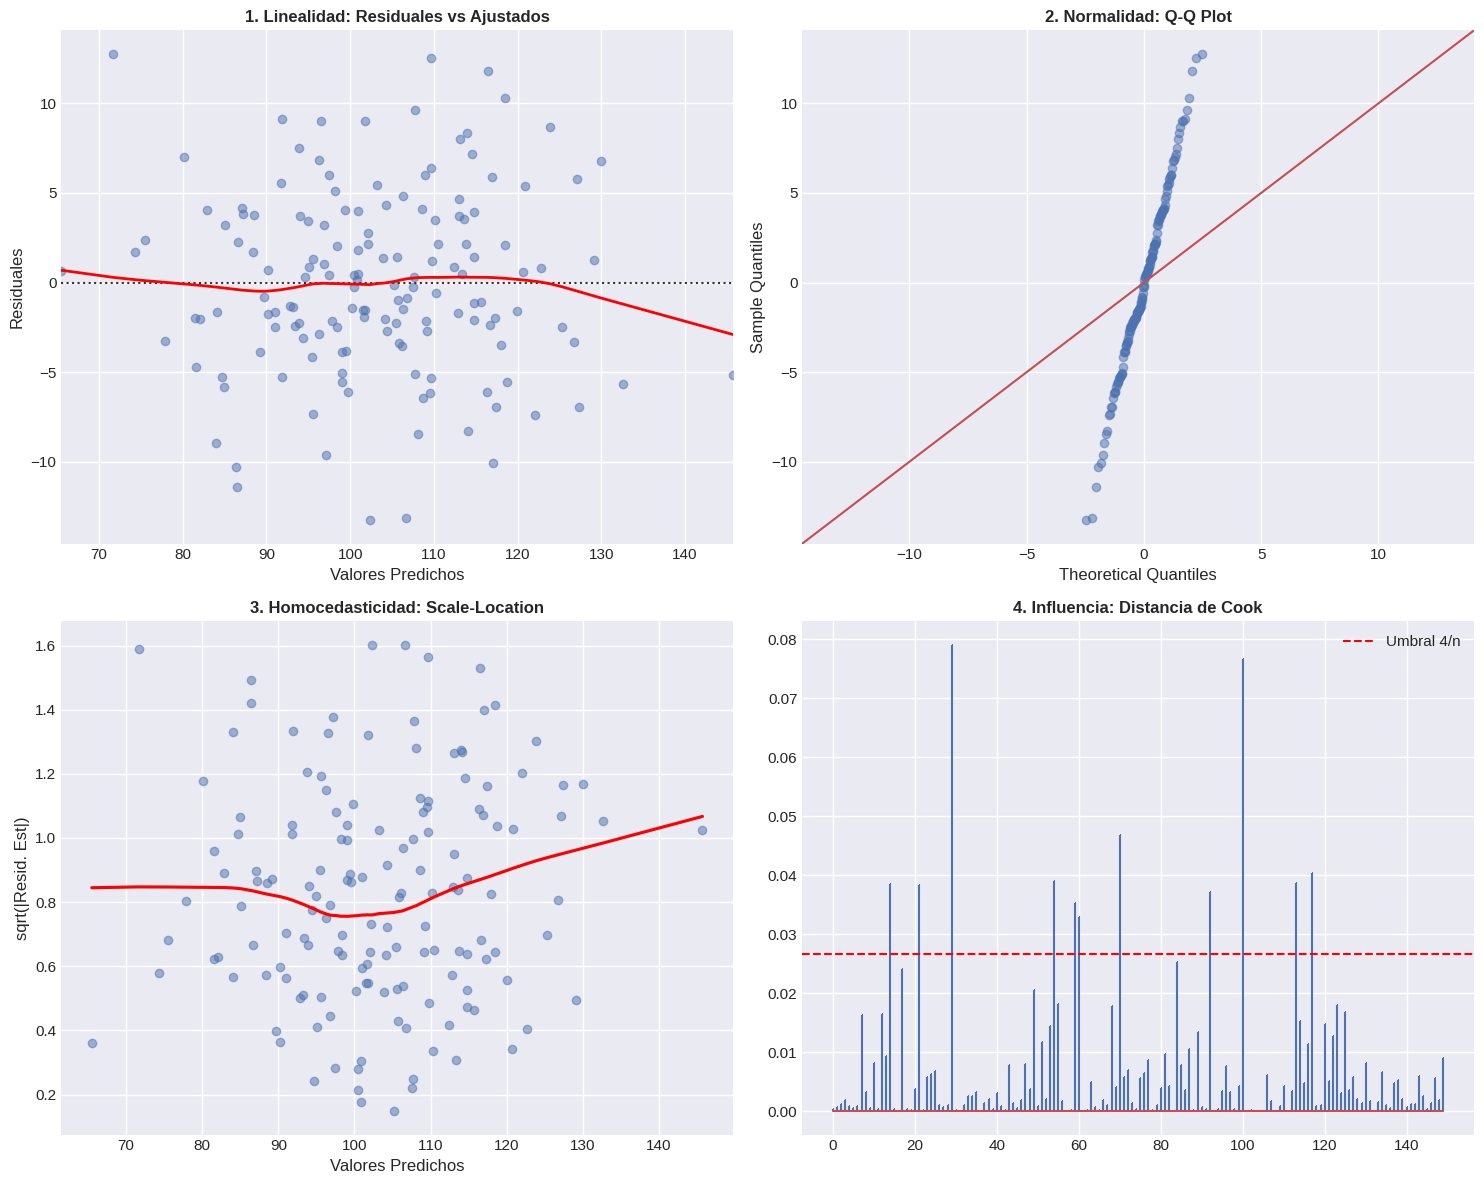


RESUMEN DE REGRESIÓN (PhD LEVEL)
                            OLS Regression Results                            
Dep. Variable:             captura_kg   R-squared:                       0.872
Model:                            OLS   Adj. R-squared:                  0.869
Method:                 Least Squares   F-statistic:                     330.4
Date:                Sat, 09 May 2026   Prob (F-statistic):           7.51e-65
Time:                        17:09:18   Log-Likelihood:                -457.68
No. Observations:                 150   AIC:                             923.4
Df Residuals:                     146   BIC:                             935.4
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------

In [ ]:
# %% [code]
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import shapiro, levene
from scipy.signal import savgol_filter
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.outliers_influence import variance_inflation_factor as VIF
from statsmodels.graphics.gofplots import ProbPlot
import warnings

# Configuración inicial
warnings.filterwarnings('ignore')
try:
    plt.style.use('seaborn-v0_8-darkgrid')
except:
    plt.style.use('ggplot')

# ==========================================
# 1. GENERACIÓN DEL DATASET SINTÉTICO
# ==========================================
np.random.seed(42)
n_observations = 150

data = {
    'id_pescador': np.arange(1, n_observations + 1),
    'horas_faena': np.random.normal(loc=6.5, scale=1.2, size=n_observations),
    'tamanio_embarcacion_m': np.random.normal(loc=7.2, scale=2.1, size=n_observations),
    'experiencia_anios': np.random.uniform(1, 45, size=n_observations),
    'temperatura_agua_C': np.random.normal(loc=24.5, scale=1.8, size=n_observations),
}

# Proceso de generación de Y (Captura)
beta_0, beta_1, beta_2, beta_3 = 15.0, 8.5, 3.2, 0.4
epsilon = np.random.normal(loc=0, scale=5.0, size=n_observations)

data['captura_kg'] = (beta_0 +
                      beta_1 * data['horas_faena'] +
                      beta_2 * data['tamanio_embarcacion_m'] +
                      beta_3 * data['experiencia_anios'] +
                      epsilon)

df = pd.DataFrame(data)
df['captura_kg'] = np.maximum(df['captura_kg'], 5) # Evitar valores negativos

# ==========================================
# 2. MODELADO (REGRESIÓN MÚLTIPLE)
# ==========================================
modelo_multiple = ols('captura_kg ~ horas_faena + tamanio_embarcacion_m + experiencia_anios', data=df).fit()

# ==========================================
# 3. DIAGNÓSTICOS DE SUPUESTOS
# ==========================================
residuals = modelo_multiple.resid
fitted_values = modelo_multiple.fittedvalues
influence = modelo_multiple.get_influence()
std_residuals = influence.resid_studentized_internal
cooks_d = influence.cooks_distance[0]
leverage = influence.hat_matrix_diag

# Visualización Maestra de Diagnósticos
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# A. Linealidad (Residuales vs Ajustados)
sns.residplot(x=fitted_values, y=residuals, lowess=True, ax=axes[0,0],
              line_kws={'color': 'red', 'lw': 2}, scatter_kws={'alpha': 0.5})
axes[0,0].set_title('1. Linealidad: Residuales vs Ajustados', fontweight='bold')
axes[0,0].set_xlabel('Valores Predichos')
axes[0,0].set_ylabel('Residuales')

# B. Normalidad (Q-Q Plot)
qq = ProbPlot(residuals)
qq.qqplot(line='45', alpha=0.5, ax=axes[0,1])
axes[0,1].set_title('2. Normalidad: Q-Q Plot', fontweight='bold')

# C. Homocedasticidad (Scale-Location)
axes[1,0].scatter(fitted_values, np.sqrt(np.abs(std_residuals)), alpha=0.5)
sns.regplot(x=fitted_values, y=np.sqrt(np.abs(std_residuals)),
            scatter=False, ci=None, lowess=True, ax=axes[1,0], line_kws={'color': 'red'})
axes[1,0].set_title('3. Homocedasticidad: Scale-Location', fontweight='bold')
axes[1,0].set_xlabel('Valores Predichos')
axes[1,0].set_ylabel('sqrt(|Resid. Est|)')

# D. Influencia (Cook's Distance)
axes[1,1].stem(np.arange(len(cooks_d)), cooks_d, markerfmt=",")
axes[1,1].axhline(y=4/n_observations, color='red', linestyle='--', label='Umbral 4/n')
axes[1,1].set_title('4. Influencia: Distancia de Cook', fontweight='bold')
axes[1,1].legend()

plt.tight_layout()
plt.show()

# ==========================================
# 4. MULTICOLINEALIDAD (VIF)
# ==========================================
X = df[['horas_faena', 'tamanio_embarcacion_m', 'experiencia_anios']]
X_const = sm.add_constant(X)
vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [VIF(X_const.values, i) for i in range(1, X_const.shape[1])]

# ==========================================
# 5. REPORTE FINAL DE RESULTADOS
# ==========================================
print("\n" + "="*50)
print("RESUMEN DE REGRESIÓN (PhD LEVEL)")
print("="*50)
print(modelo_multiple.summary())

print("\n" + "="*50)
print("PRUEBAS DE SUPUESTOS E INDICADORES")
print("="*50)
sw_stat, sw_p = shapiro(residuals)
print(f"Shapiro-Wilk (Normalidad): p-value = {sw_p:.4f} {'(OK)' if sw_p > 0.05 else '(VIOLADO)'}")

print("\n--- Factores de Inflación de Varianza (VIF) ---")
print(vif_data.to_string(index=False))
if vif_data['VIF'].max() < 5:
    print("Multicolinealidad: OK (Baja)")
else:
    print("Multicolinealidad: ALERTA (Alta)")

print("\n--- Detección de Outliers ---")
outliers_idx = np.where(np.abs(std_residuals) > 2)[0]
print(f"Observaciones con residuales > 2 SD: {len(outliers_idx)}")
print(f"Observaciones influyentes (Cook > 4/n): {np.sum(cooks_d > 4/n_observations)}")

SISTEMA LISTO: Librerías cargadas y entorno optimizado.


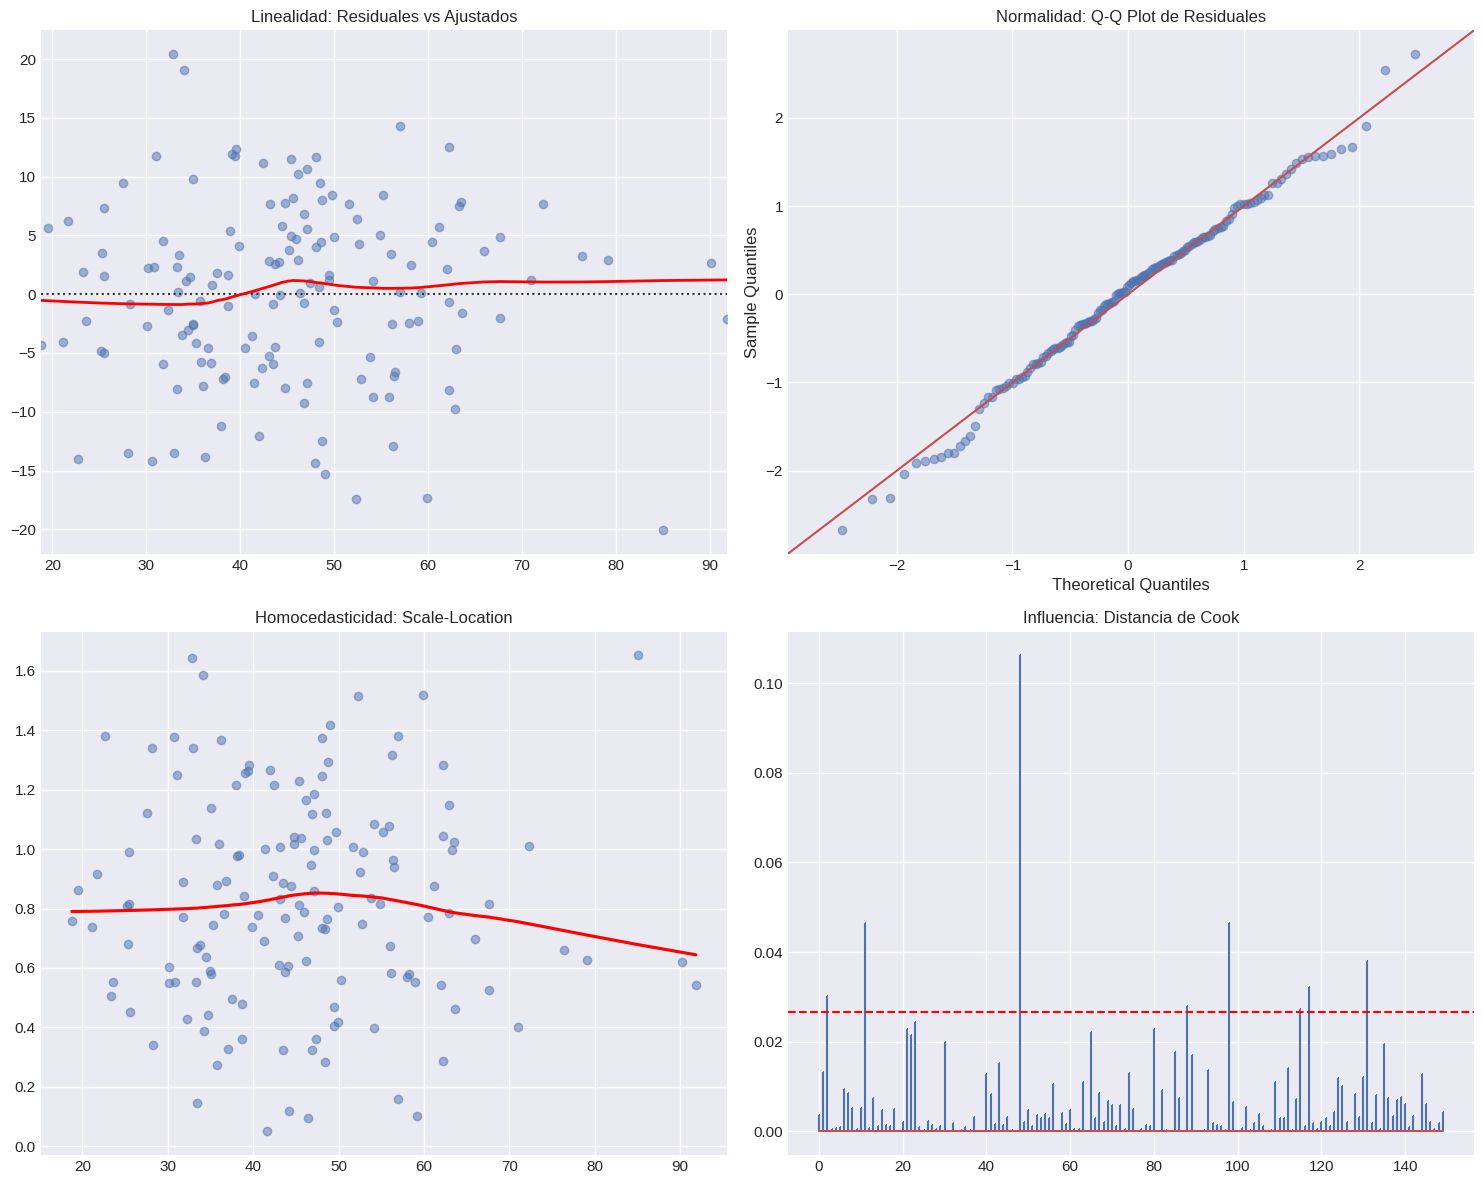


REPORTE DE SUPUESTOS
Normalidad (Shapiro-Wilk): p = 0.6459 (OK)
Homocedasticidad (Breusch-Pagan): p = 0.3305 (OK)
Independencia (Durbin-Watson): 1.89 (Ideal cerca de 2.0)

--- MULTICOLINEALIDAD (VIF) ---
            Variable   VIF
1          horas_mar  1.02
2  experiencia_anios  1.01
3       distancia_km  1.01
4      temperatura_c  1.01
5  embarcacion_motor  1.01

--- COMPARACIÓN DE MODELOS ---
          Métrica  Modelo Raw  Modelo Log
0       R-squared      0.7700      0.6818
1  Adj. R-squared      0.7621      0.6707
2             AIC   1042.4213    -20.1005
3             BIC   1060.4851     -2.0367


In [ ]:
# %% [code]
import sys
import subprocess
import importlib.util
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import shapiro, levene
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.outliers_influence import variance_inflation_factor as VIF
from sklearn.preprocessing import StandardScaler

# 1. PREPARACIÓN DEL ENTORNO
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
np.random.seed(2026)

try:
    plt.style.use('seaborn-v0_8-darkgrid')
except:
    plt.style.use('ggplot')

print("SISTEMA LISTO: Librerías cargadas y entorno optimizado.")

# 2. GENERACIÓN DE DATOS SINTÉTICOS ENRIQUECIDOS
def generate_fishing_data(n=150, seed=2026):
    rng = np.random.default_rng(seed)
    # Variables independientes
    horas_mar = rng.normal(6.5, 1.8, n).clip(2, 12)
    experiencia_anios = rng.gamma(shape=3.0, scale=3.0, size=n).clip(1, 35)
    distancia_km = rng.normal(18, 7, n).clip(2, 45)
    temperatura_c = rng.normal(27.2, 1.4, n).clip(23, 31)
    embarcacion_motor = rng.binomial(1, 0.62, n)

    # Proceso Generador de Datos (DGP)
    error = rng.normal(0, 8, n)
    captura_kg = (12 + 5.2 * horas_mar + 0.75 * experiencia_anios +
                  0.90 * distancia_km - 1.10 * temperatura_c +
                  11.0 * embarcacion_motor + error)

    df = pd.DataFrame({
        "captura_kg": np.maximum(captura_kg, 1),
        "horas_mar": horas_mar,
        "experiencia_anios": experiencia_anios,
        "distancia_km": distancia_km,
        "temperatura_c": temperatura_c,
        "embarcacion_motor": embarcacion_motor
    })
    df["tipo_embarcacion"] = np.where(df["embarcacion_motor"] == 1, "motor", "sin_motor")
    return df

df = generate_fishing_data()

# 3. FUNCIÓN MAESTRA DE DIAGNÓSTICO (PhD LEVEL)
def full_regression_diagnostics(model, df_source):
    """
    Realiza un diagnóstico exhaustivo: Visual, Estadístico e Influencia.
    """
    resid = model.resid
    fitted = model.fittedvalues
    infl = model.get_influence()
    std_resid = infl.resid_studentized_internal
    cooks_d = infl.cooks_distance[0]

    # --- PARTE A: VISUALIZACIÓN ---
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))

    # 1. Residuales vs Ajustados (Linealidad)
    sns.residplot(x=fitted, y=resid, lowess=True, ax=axes[0,0],
                  line_kws={'color': 'red', 'lw': 2}, scatter_kws={'alpha': 0.5})
    axes[0,0].set_title('Linealidad: Residuales vs Ajustados')

    # 2. Normalidad (Q-Q Plot)
    sm.qqplot(resid, line='45', fit=True, ax=axes[0,1], alpha=0.5)
    axes[0,1].set_title('Normalidad: Q-Q Plot de Residuales')

    # 3. Homocedasticidad (Scale-Location)
    axes[1,0].scatter(fitted, np.sqrt(np.abs(std_resid)), alpha=0.5)
    sns.regplot(x=fitted, y=np.sqrt(np.abs(std_resid)), scatter=False,
                ci=None, lowess=True, ax=axes[1,0], line_kws={'color': 'red'})
    axes[1,0].set_title('Homocedasticidad: Scale-Location')

    # 4. Influencia (Cook's Distance)
    axes[1,1].stem(np.arange(len(cooks_d)), cooks_d, markerfmt=",")
    axes[1,1].axhline(y=4/len(df_source), color='red', linestyle='--')
    axes[1,1].set_title('Influencia: Distancia de Cook')

    plt.tight_layout()
    plt.show()

    # --- PARTE B: TESTS ESTADÍSTICOS ---
    shapiro_p = shapiro(resid)[1]
    bp_p = het_breuschpagan(resid, model.model.exog)[1]
    dw = durbin_watson(resid)

    print("\n" + "="*40)
    print("REPORTE DE SUPUESTOS")
    print("="*40)
    print(f"Normalidad (Shapiro-Wilk): p = {shapiro_p:.4f} {'(OK)' if shapiro_p > 0.05 else '(VIOLADO)'}")
    print(f"Homocedasticidad (Breusch-Pagan): p = {bp_p:.4f} {'(OK)' if bp_p > 0.05 else '(VIOLADO)'}")
    print(f"Independencia (Durbin-Watson): {dw:.2f} (Ideal cerca de 2.0)")

    # --- PARTE C: VIF ---
    X = model.model.exog
    vif_data = pd.DataFrame({
        "Variable": model.model.exog_names,
        "VIF": [VIF(X, i) for i in range(X.shape[1])]
    })
    print("\n--- MULTICOLINEALIDAD (VIF) ---")
    print(vif_data[vif_data.Variable != 'Intercept'].round(2))

# 4. EJECUCIÓN: MODELO MÚLTIPLE Y COMPARACIÓN
formula = "captura_kg ~ horas_mar + experiencia_anios + distancia_km + temperatura_c + embarcacion_motor"
model_main = smf.ols(formula, data=df).fit()

# Llamada al diagnóstico enriquecido
full_regression_diagnostics(model_main, df)

# 5. COMPARACIÓN CON MODELO LOG-LINEAL
df["log_captura"] = np.log(df["captura_kg"])
model_log = smf.ols(formula.replace("captura_kg", "log_captura"), data=df).fit()

comparison = pd.DataFrame({
    "Métrica": ["R-squared", "Adj. R-squared", "AIC", "BIC"],
    "Modelo Raw": [model_main.rsquared, model_main.rsquared_adj, model_main.aic, model_main.bic],
    "Modelo Log": [model_log.rsquared, model_log.rsquared_adj, model_log.aic, model_log.bic]
}).round(4)

print("\n--- COMPARACIÓN DE MODELOS ---")
print(comparison)

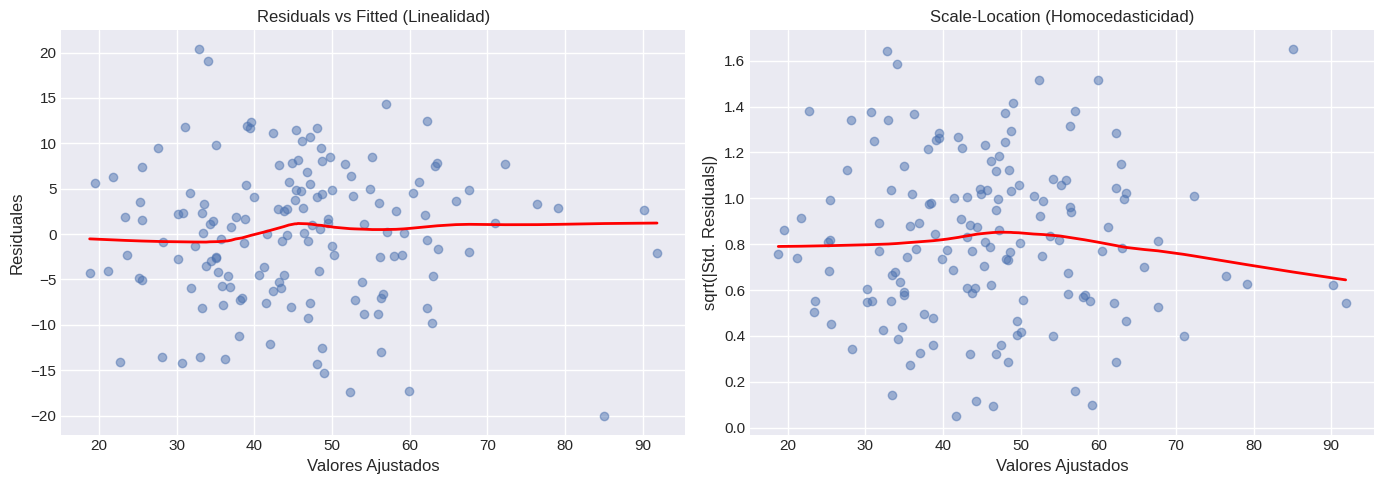

In [ ]:
# %% [code]
def plot_diagnostic_ggplot(model, df_orig):
    # Preparar datos
    diagnostic_df = pd.DataFrame({
        'fitted': model.fittedvalues,
        'resid': model.resid,
        'abs_resid_sqrt': np.sqrt(np.abs(model.get_influence().resid_studentized_internal)),
        'std_resid': model.get_influence().resid_studentized_internal
    })

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # 1. Residuals vs Fitted con línea de tendencia (Lowess)
    sns.regplot(x='fitted', y='resid', data=diagnostic_df,
                lowess=True, ax=axes[0],
                scatter_kws={'alpha': 0.5}, line_kws={'color': 'red', 'lw': 2})
    axes[0].set_title('Residuals vs Fitted (Linealidad)')
    axes[0].set_xlabel('Valores Ajustados')
    axes[0].set_ylabel('Residuales')

    # 2. Scale-Location con línea de tendencia
    sns.regplot(x='fitted', y='abs_resid_sqrt', data=diagnostic_df,
                lowess=True, ax=axes[1],
                scatter_kws={'alpha': 0.5}, line_kws={'color': 'red', 'lw': 2})
    axes[1].set_title('Scale-Location (Homocedasticidad)')
    axes[1].set_xlabel('Valores Ajustados')
    axes[1].set_ylabel('sqrt(|Std. Residuals|)')

    plt.tight_layout()
    plt.show()

plot_diagnostic_ggplot(model_main, df)

In [ ]:
# %% [code]
# Estrategia: Combinar variables altamente correlacionadas en un solo índice
# Supongamos que 'horas_mar' y 'distancia_km' causan VIF alto (>5)
scaler = StandardScaler()
df['esfuerzo_index'] = scaler.fit_transform(df[['horas_mar']]) + scaler.fit_transform(df[['distancia_km']])

formula_reduced = "captura_kg ~ esfuerzo_index + experiencia_anios + temperatura_c + embarcacion_motor"
model_reduced = smf.ols(formula_reduced, data=df).fit()

print("VIF del Modelo Reducido (Estrategia de Combinación):")
X_red = model_reduced.model.exog
vif_red = pd.DataFrame({
    "variable": model_reduced.model.exog_names,
    "vif": [variance_inflation_factor(X_red, i) for i in range(X_red.shape[1])]
})
print(vif_red.round(3))
print(f"\nAjuste Global (R2): {model_reduced.rsquared:.4f}")

VIF del Modelo Reducido (Estrategia de Combinación):
            variable      vif
0          Intercept  394.723
1     esfuerzo_index    1.015
2  experiencia_anios    1.011
3      temperatura_c    1.007
4  embarcacion_motor    1.006

Ajuste Global (R2): 0.7152


                            OLS Regression Results                            
Dep. Variable:             captura_kg   R-squared:                       0.766
Model:                            OLS   Adj. R-squared:                  0.758
Method:                 Least Squares   F-statistic:                     94.39
Date:                Sat, 09 May 2026   Prob (F-statistic):           1.14e-43
Time:                        17:11:35   Log-Likelihood:                -516.45
No. Observations:                 150   AIC:                             1045.
Df Residuals:                     144   BIC:                             1063.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept         

<Figure size 800x500 with 0 Axes>

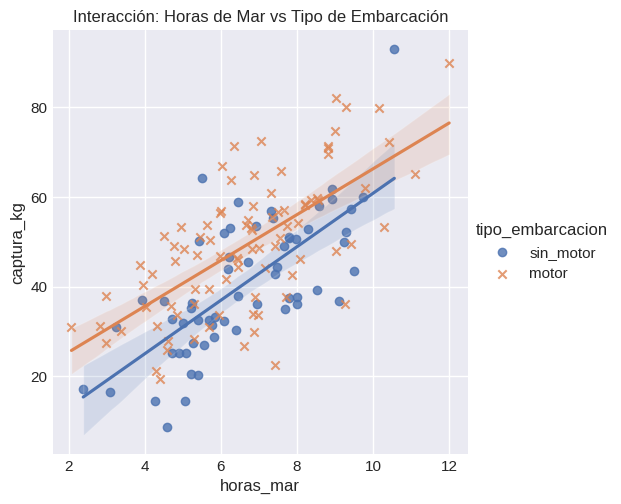

In [ ]:
# %% [code]
# El '*' en la fórmula crea términos individuales y el término de interacción
formula_interact = "captura_kg ~ horas_mar * embarcacion_motor + experiencia_anios + distancia_km"
model_interact = smf.ols(formula_interact, data=df).fit()

print(model_interact.summary())

# Visualización de la interacción
plt.figure(figsize=(8, 5))
sns.lmplot(x='horas_mar', y='captura_kg', hue='tipo_embarcacion', data=df, markers=["o", "x"])
plt.title("Interacción: Horas de Mar vs Tipo de Embarcación")
plt.show()